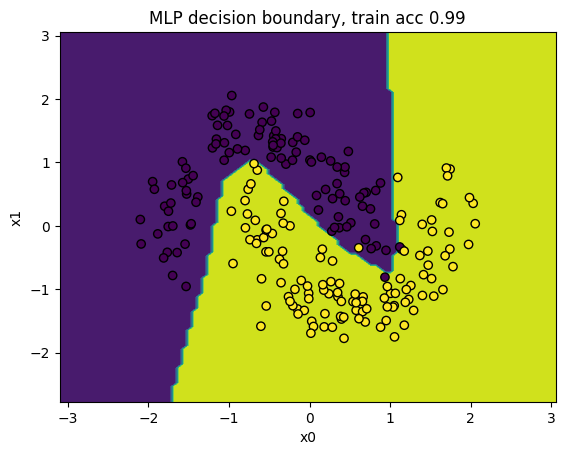

In [19]:
# Decision boundary example for sklearn MLPClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Data
X, y = make_moons(n_samples=300, noise=0.20, random_state=2)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

# Scale
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Model
clf = MLPClassifier(hidden_layer_sizes=(50,30), activation='relu',
                    solver='adam', max_iter=2000, random_state=1)
clf.fit(X_train_s, y_train)

# Decision boundary using DecisionBoundaryDisplay (sklearn >= 1.1)
disp = DecisionBoundaryDisplay.from_estimator(clf, X_train_s, response_method="predict",
                                              xlabel='x0', ylabel='x1', plot_method='contourf')
plt.scatter(X_train_s[:,0], X_train_s[:,1], c=y_train, edgecolor='k')
plt.title(f"MLP decision boundary, train acc {clf.score(X_train_s, y_train):.2f}")
plt.show()


---

In [ ]:
!pip install imageio[ffmpeg]

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from matplotlib.colors import ListedColormap
import imageio

# Load Iris dataset
iris = load_iris()
X = iris.data[:, :2]  # only 2D for visualization
y = iris.target

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Classifier
clf = SGDClassifier(loss="log_loss", max_iter=1, warm_start=True, eta0=0.05, learning_rate='constant', random_state=0)

# Mesh grid
x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Colormaps
cm = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cm_bright = ListedColormap(['#FF0000', '#00AA00', '#0000FF'])

# Prepare figure
fig, ax = plt.subplots(figsize=(6,5))
ax.set_xlabel("Feature 1 (standardized)")
ax.set_ylabel("Feature 2 (standardized)")

# Store frames as images
frames = []

for epoch in range(150):
    clf.fit(X, y)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.clear()
    ax.contourf(xx, yy, Z, alpha=0.5, cmap=cm)
    ax.scatter(X[:,0], X[:,1], c=y, cmap=cm_bright, edgecolors='k')
    ax.set_title(f"Epoch {epoch+1}")
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    
    # Save current frame to a numpy array
    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames.append(image)

plt.close(fig)

# Save frames as MP4 using imageio
imageio.mimsave("iris_decision_boundary.mp4", frames, fps=5)
# Or save as GIF
imageio.mimsave("iris_decision_boundary.gif", frames, fps=5)


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\User\AppData\Local\Temp\ipykernel_16732\4071052705.py:54: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\User\AppData\Local\Temp\ipykernel_16732\4071052705.py:54: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap
import imageio

# Load Iris dataset (use first two features for 2D visualization)
iris = load_iris()
X = iris.data[:, :2]
y = iris.target
class_names = iris.target_names

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# MLP classifier
clf = MLPClassifier(hidden_layer_sizes=(10, 10),
                    activation='relu',
                    solver='sgd',
                    learning_rate_init=0.05,
                    max_iter=1,        # train 1 epoch per loop
                    warm_start=True,   # continue training each iteration
                    random_state=0)

# Create mesh grid for plotting decision boundaries
x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Colormaps for 3 classes
cm = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cm_bright = ListedColormap(['#FF0000', '#00AA00', '#0000FF'])

# Prepare figure
fig, ax = plt.subplots(figsize=(6,5))
ax.set_xlabel("Feature 1 (standardized)")
ax.set_ylabel("Feature 2 (standardized)")

frames = []

# Train for multiple epochs and capture frames
for epoch in range(50):
    clf.fit(X, y)
    
    # Predict on mesh grid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.clear()
    # Decision boundary
    ax.contourf(xx, yy, Z, alpha=0.5, cmap=cm)
    # Plot points
    for i, color, label in zip(range(3), ['#FF0000','#00AA00','#0000FF'], class_names):
        ax.scatter(X[y==i,0], X[y==i,1], c=color, label=label, edgecolors='k')
    
    ax.set_title(f"MLP Decision Boundary - Epoch {epoch+1}")
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.legend(loc='upper right')
    
    # Capture frame as image
    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames.append(image)

plt.close(fig)

# Save as MP4
imageio.mimsave("iris_mlp_decision_boundary.mp4", frames, fps=5)
# Or as GIF
# imageio.mimsave("iris_mlp_decision_boundary.gif", frames, fps=5)

print("Animation saved as iris_mlp_decision_boundary.mp4")


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\User\AppData\Local\Temp\ipykernel_16732\1848781378.py:68: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\User\AppData\Local\Temp\ipykernel_16732\1848781378.py:68: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba inste

Animation saved as iris_mlp_decision_boundary.mp4


---

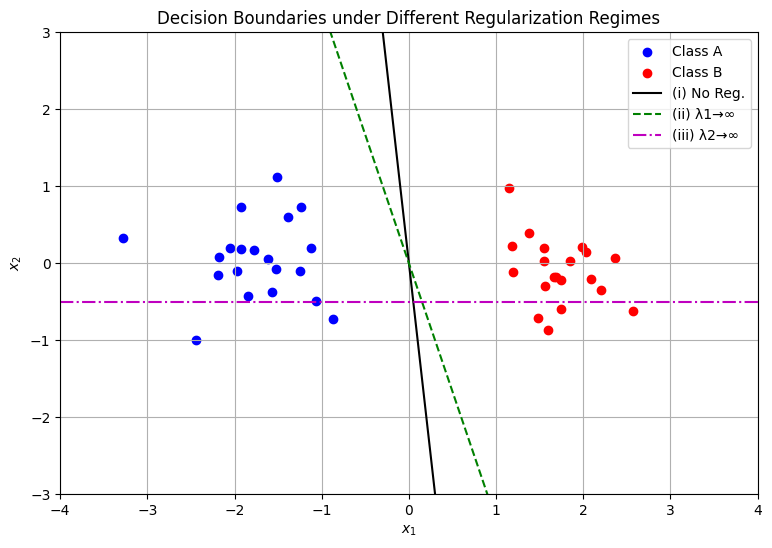

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data roughly like "Class A (left)" and "Class B (right)"
np.random.seed(0)
classA = np.random.randn(20, 2) * 0.5 + np.array([-2, 0])
classB = np.random.randn(20, 2) * 0.5 + np.array([2, 0])

# Create a grid for plotting decision boundaries
x1_vals = np.linspace(-4, 4, 200)
x2_vals = np.linspace(-3, 3, 200)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

# Define example weights representing each regime
# i. No regularization
w0_1, w1_1, w2_1 = 0.0, 1.0, 0.1  # general line separating roughly left-right
# ii. lambda1 -> ∞ (bias = 0) -> line through origin
w0_2, w1_2, w2_2 = 0.0, 1.0, 0.3
# iii. lambda2 -> ∞ (w1=0) -> horizontal line parallel to x1 axis
w0_3, w1_3, w2_3 = 0.5, 0.0, 1.0

# Decision boundaries: w0 + w1*x1 + w2*x2 = 0 => x2 = -(w0 + w1*x1)/w2
def decision_line(w0, w1, w2, x):
    return -(w0 + w1 * x) / w2

# Plot
plt.figure(figsize=(9, 6))
plt.scatter(classA[:, 0], classA[:, 1], color='blue', label='Class A')
plt.scatter(classB[:, 0], classB[:, 1], color='red', label='Class B')

# i. no regularization
plt.plot(x1_vals, decision_line(w0_1, w1_1, w2_1, x1_vals), 'k-', label='(i) No Reg.')
# ii. bias = 0
plt.plot(x1_vals, decision_line(w0_2, w1_2, w2_2, x1_vals), 'g--', label='(ii) λ1→∞')
# iii. w1 = 0 (horizontal)
plt.plot(x1_vals, decision_line(w0_3, w1_3, w2_3, x1_vals), 'm-.', label='(iii) λ2→∞')

plt.xlim(-4, 4)
plt.ylim(-3, 3)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Decision Boundaries under Different Regularization Regimes')
plt.legend()
plt.grid(True)
plt.show()


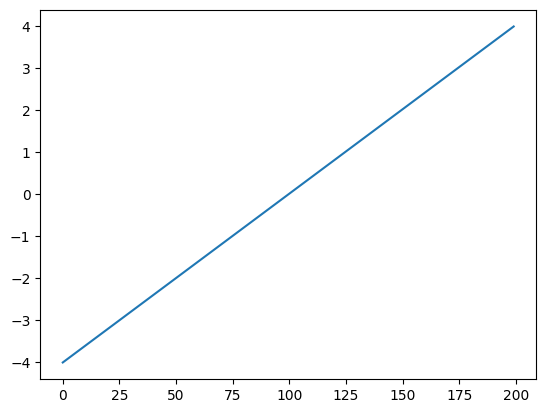

In [2]:
plt.plot(x1_vals)

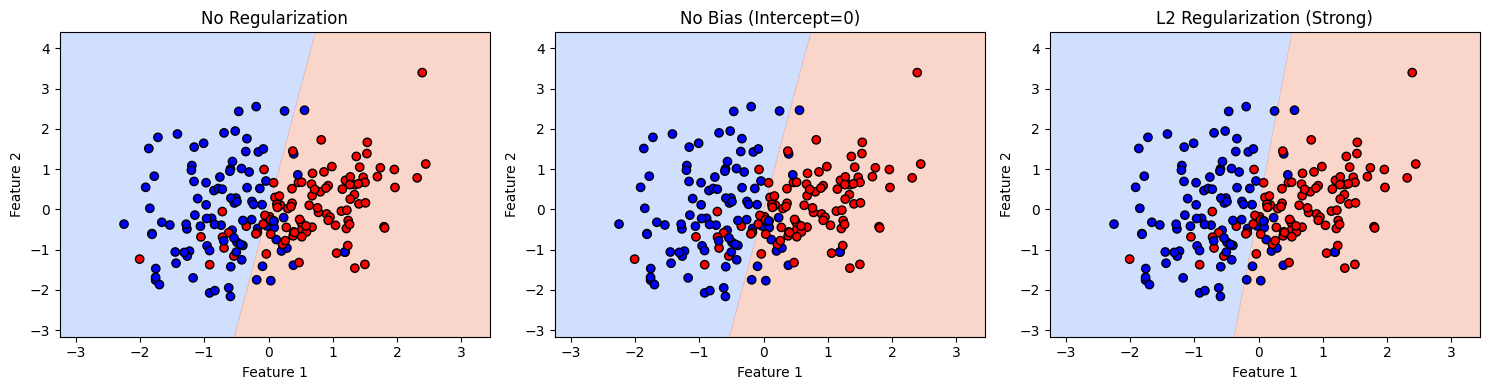

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Create synthetic dataset similar to figure in question
np.random.seed(42)
classA = np.random.randn(50, 2) * 0.8 + np.array([-6, 0])
classB = np.random.randn(50, 2) * 0.8 + np.array([0, 0])
X = np.vstack((classA, classB))
y = np.hstack((np.zeros(50), np.ones(50)))

# Helper function to plot decision boundary
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

# Scenario i: λ1 = 0, λ2 = 0 (no regularization)
model1 = LogisticRegression(penalty='none', solver='lbfgs')
model1.fit(X, y)

# Scenario ii: λ1 → ∞ and λ2 = 0 (bias forced to 0)
# Equivalent: fit_intercept=False to remove bias
model2 = LogisticRegression(penalty='none', fit_intercept=False, solver='lbfgs')
model2.fit(X, y)

# Scenario iii: λ1 = 0 and λ2 → ∞ (w1 heavily penalized)
# Strong L2 regularization on weights only
model3 = LogisticRegression(penalty='l2', C=1e-5, solver='lbfgs')
model3.fit(X, y)

# Plot all scenarios
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_decision_boundary(model1, X, y, axes[0], "(i) λ₁=0, λ₂=0 (No Reg.)")
plot_decision_boundary(model2, X, y, axes[1], "(ii) λ₁→∞, λ₂=0 (No Bias Term)")
plot_decision_boundary(model3, X, y, axes[2], "(iii) λ₁=0, λ₂→∞ (w₁ Penalized)")

plt.tight_layout()
plt.show()


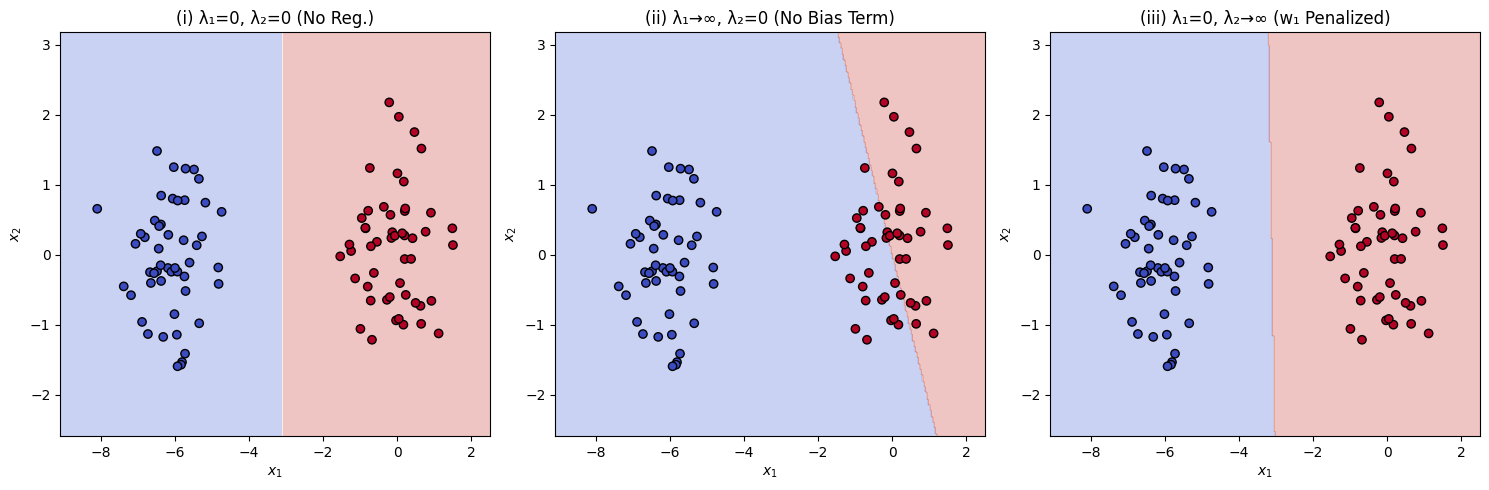

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Create synthetic dataset similar to figure in question
np.random.seed(42)
classA = np.random.randn(50, 2) * 0.8 + np.array([-6, 0])
classB = np.random.randn(50, 2) * 0.8 + np.array([0, 0])
X = np.vstack((classA, classB))
y = np.hstack((np.zeros(50), np.ones(50)))

# Helper function to plot decision boundary
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    ax.set_title(title)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

# Scenario i: λ1 = 0, λ2 = 0 (no regularization)
model1 = LogisticRegression(solver='lbfgs')
model1.fit(X, y)

# Scenario ii: λ1 → ∞ and λ2 = 0 (bias forced to 0)
# Equivalent: fit_intercept=False to remove bias
model2 = LogisticRegression(fit_intercept=False, solver='lbfgs')
model2.fit(X, y)

# Scenario iii: λ1 = 0 and λ2 → ∞ (w1 heavily penalized)
# Strong L2 regularization on weights only
model3 = LogisticRegression(penalty='l2', C=1e-5, solver='lbfgs')
model3.fit(X, y)

# Plot all scenarios
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_decision_boundary(model1, X, y, axes[0], "(i) λ₁=0, λ₂=0 (No Reg.)")
plot_decision_boundary(model2, X, y, axes[1], "(ii) λ₁→∞, λ₂=0 (No Bias Term)")
plot_decision_boundary(model3, X, y, axes[2], "(iii) λ₁=0, λ₂→∞ (w₁ Penalized)")

plt.tight_layout()
plt.show()


In [9]:
np.c_[xx.ravel(), yy.ravel()].shape

(90000, 2)

$$
p(y=c_k) = \frac{\text{Nb. of samples in class } c_k}{\text{total Nb. of samples}}
